In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
dataset = pd.read_csv("Teen_Mental_Health_Dataset (1).csv")

print(dataset.head(10))

Saving Teen_Mental_Health_Dataset (1).csv to Teen_Mental_Health_Dataset (1) (1).csv
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   
5   19  female                       7.4           Both          4.4   
6   18  female                       2.5      Instagram          6.4   
7   16    male                       4.0           Both          4.2   
8   19  female                       3.3         TikTok          5.0   
9   15    male                       1.9         TikTok          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01  

In [4]:
print(dataset.shape)
print(dataset.isnull().sum())
print(dataset.isnull().sum().sum())                        # no null value

(1200, 13)
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64
0


In [5]:
#encoding
from sklearn.preprocessing import OrdinalEncoder
dataset ["social_interaction_level"].unique()
en_data_ord=[["low","medium","high"]]
oen= OrdinalEncoder(categories=en_data_ord)
dataset["social_interaction_level"]= oen.fit_transform(dataset[["social_interaction_level"]])

from sklearn.preprocessing import OrdinalEncoder
dataset ["gender"].unique()
en_data_ord1=[["male","female"]]
oen= OrdinalEncoder(categories=en_data_ord1)
dataset["gender"]= oen.fit_transform(dataset[["gender"]])

from sklearn.preprocessing import OrdinalEncoder
dataset ["platform_usage"].unique()
en_data_ord2=[["Instagram","TikTok","Both"]]
oen= OrdinalEncoder(categories=en_data_ord2)
dataset["platform_usage"]= oen.fit_transform(dataset[["platform_usage"]])

In [6]:
dataset.head(3)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,0.0,7.9,0.0,7.4,2.9,3.01,1.5,0.0,2,2,1,0
1,19,1.0,1.9,1.0,8.0,2.9,3.22,0.8,2.0,8,1,10,0
2,17,1.0,1.3,0.0,7.6,0.5,3.92,0.0,2.0,2,4,2,0


In [7]:
#outlier
dataset.describe()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,0.487500,4.536667,0.983333,6.449417,1.740333,2.990383,1.014500,0.961667,5.445833,5.636667,5.565000,0.025833
std,2.021947,0.500052,2.029599,0.817687,1.442677,0.716660,0.576758,0.582185,0.807718,2.903290,2.859453,2.830627,0.158704
min,13.000000,0.000000,1.000000,0.000000,4.000000,0.500000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,0.000000,2.800000,0.000000,5.200000,1.100000,2.500000,0.500000,0.000000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,0.000000,4.500000,1.000000,6.500000,1.800000,2.990000,1.000000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,1.000000,6.300000,2.000000,7.600000,2.400000,3.480000,1.500000,2.000000,8.000000,8.000000,8.000000,0.000000
max,19.000000,1.000000,8.000000,2.000000,9.000000,3.000000,4.000000,2.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [9]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

num_cols = [
    "age","age","daily_social_media_hours","platform_usage",
    "sleep_hours","screen_time_before_sleep","academic_performance",
    "social_interaction_level","physical_activity","stress_level",
    "anxiety_level","addiction_level"
]

dataset[num_cols] = ms.fit_transform(dataset[num_cols])

print(dataset.head(3))

        age  gender  daily_social_media_hours  platform_usage  sleep_hours  \
0  0.166667     0.0                  0.985714             0.0         0.68   
1  1.000000     1.0                  0.128571             0.5         0.80   
2  0.666667     1.0                  0.042857             0.0         0.72   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                      0.96                 0.505               0.75   
1                      0.96                 0.610               0.40   
2                      0.00                 0.960               0.00   

   social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                       0.0      0.111111       0.111111         0.000000   
1                       1.0      0.777778       0.000000         1.000000   
2                       1.0      0.111111       0.333333         0.111111   

   depression_label  
0                 0  
1                 0  
2                 0  


In [29]:
import pickle

pickle.dump(ms, open("Min_Max_scaler.pkl", "wb"))

<function matplotlib.pyplot.show(close=None, block=None)>

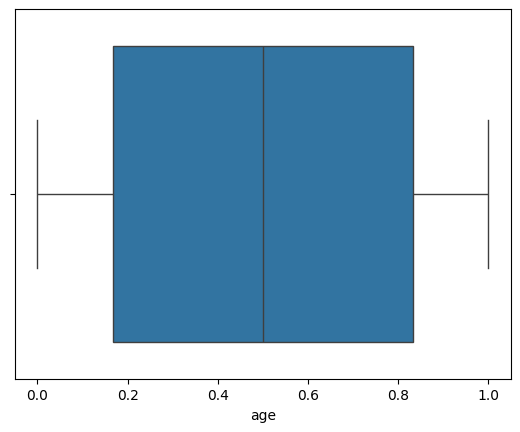

In [10]:
sns.boxplot(x= "age",data=dataset)
plt.show
#no outlier (no large diffrence between minimum and maximum values in any column)

/tmp/ipykernel_2226/1637460605.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["age"])    # no long tail hence no outlier


<function matplotlib.pyplot.show(close=None, block=None)>

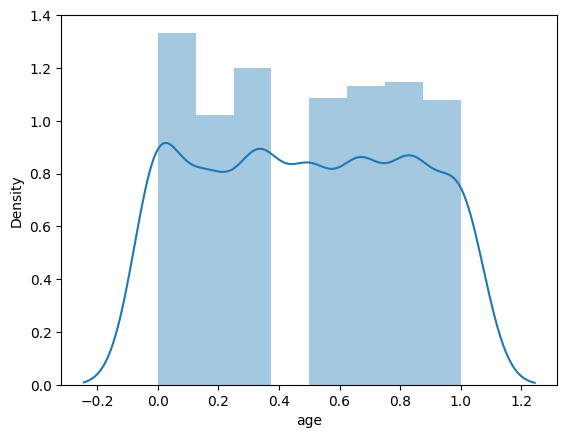

In [11]:
sns.distplot(dataset["age"])    # no long tail hence no outlier
plt.show

In [13]:
dataset.drop_duplicates(inplace=True)
dataset.shape

(1200, 13)

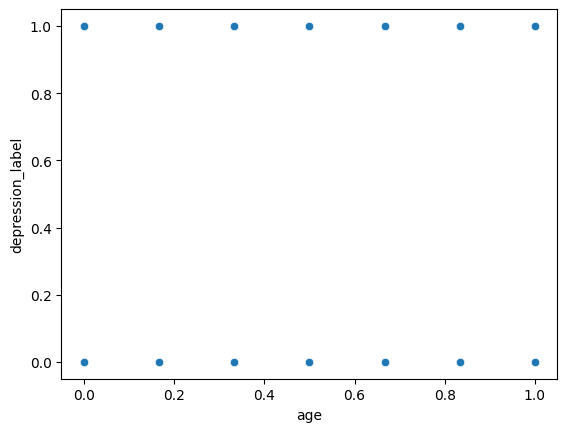

In [14]:
sns.scatterplot(x="age", y="depression_label", data=dataset)
plt.show()

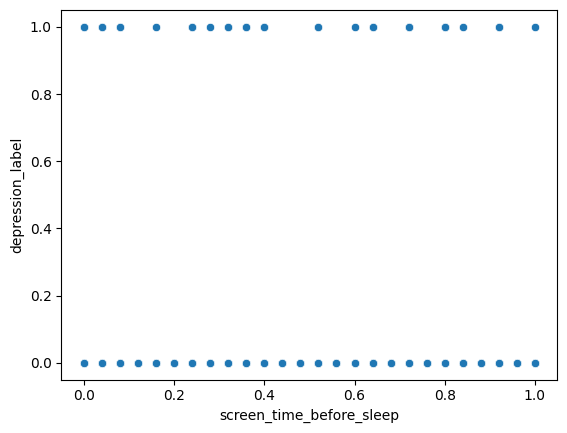

In [15]:
sns.scatterplot(x="screen_time_before_sleep", y="depression_label", data=dataset)
plt.show()

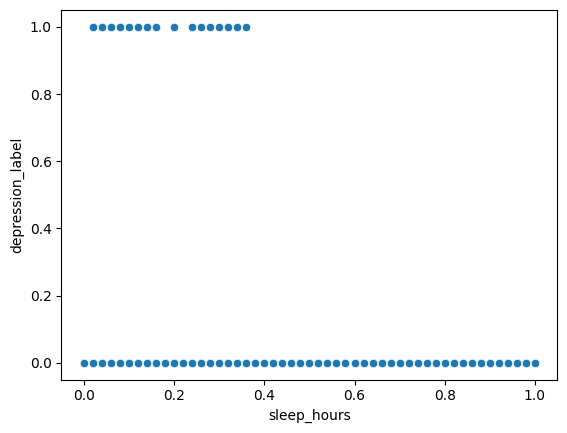

In [16]:
sns.scatterplot(x="sleep_hours", y="depression_label", data=dataset)
plt.show()

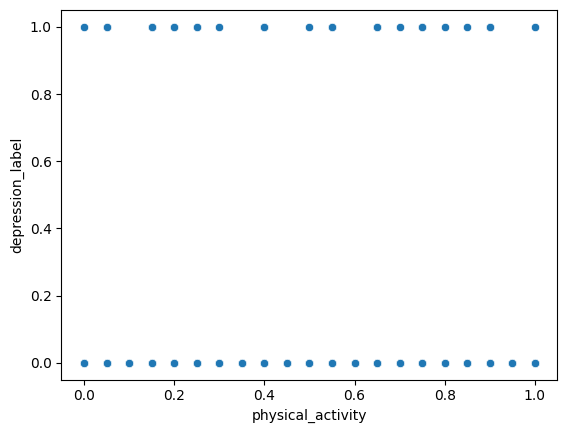

In [17]:
sns.scatterplot(x="physical_activity", y="depression_label", data=dataset)
plt.show()

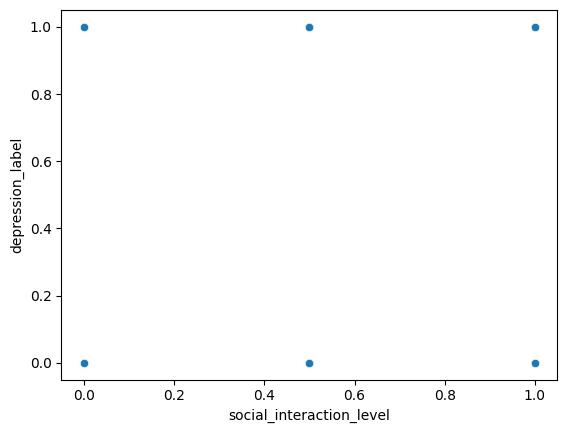

In [18]:
sns.scatterplot(x="social_interaction_level", y="depression_label", data=dataset)
plt.show()

In [19]:
#all have sigmoid function relation
# use logistic regression

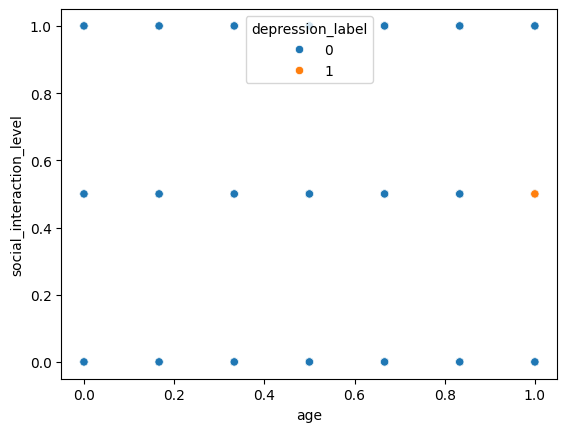

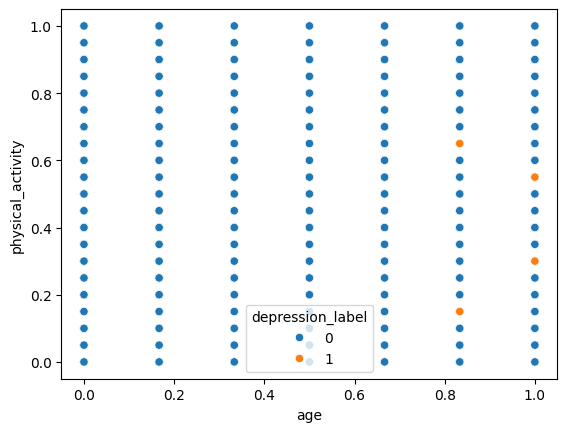

In [20]:
sns.scatterplot(x="age", y="social_interaction_level",data=dataset, hue="depression_label")
plt.show()
sns.scatterplot(x="age", y="physical_activity",data=dataset, hue="depression_label")
plt.show()
#not linearly seperable,we should use logistic regression with polynomial features

In [21]:
""" input_data= dataset.iloc[:,:-1]
output_data=dataset ["depression_label"]
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(input_data,output_data,test_size=0.2,random_state=42)
from sklearn.preprocessing import PolynomialFeatures
pf=PolynomialFeatures(degree=2)
pf.fit(input_data)
x = pd.DataFrame(pf.transform(input_data))
from sklearn.linear_model import LinearRegression
lr= LinearRegression()
lr.fit(x_train,y_train)"""

' input_data= dataset.iloc[:,:-1]\noutput_data=dataset ["depression_label"]\nfrom sklearn.model_selection import train_test_split\nx_train, x_test, y_train, y_test = train_test_split(input_data,output_data,test_size=0.2,random_state=42)\nfrom sklearn.preprocessing import PolynomialFeatures\npf=PolynomialFeatures(degree=2)\npf.fit(input_data)\nx = pd.DataFrame(pf.transform(input_data))\nfrom sklearn.linear_model import LinearRegression\nlr= LinearRegression()\nlr.fit(x_train,y_train)'

In [22]:
#lr.score(x_test,y_test)*100

In [23]:
#imbalancing bcz output 0 is more and model is baised
input_data= dataset.iloc[:,:-1]
output_data=dataset ["depression_label"]
from imblearn.over_sampling import RandomOverSampler
ro=RandomOverSampler(random_state=42)
ro_input_data,ro_output_data= ro.fit_resample(input_data,output_data)

print(ro_output_data.value_counts())

depression_label
0    1169
1    1169
Name: count, dtype: int64


In [24]:

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(ro_input_data,ro_output_data,test_size=0.25,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1753, 12)
(585, 12)
(1753,)
(585,)


In [41]:
from sklearn.preprocessing import PolynomialFeatures
pf=PolynomialFeatures(degree=2)
pf.fit(ro_input_data)
x = pd.DataFrame(pf.transform(ro_input_data))

In [42]:
from sklearn.linear_model import LogisticRegression
lr= LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [43]:
lr.score(x_test,y_test)*100

95.04273504273503

In [30]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
cf=confusion_matrix(y_test,lr.predict(x_test))
cf

array([[276,  16],
       [ 13, 280]])

<Axes: >

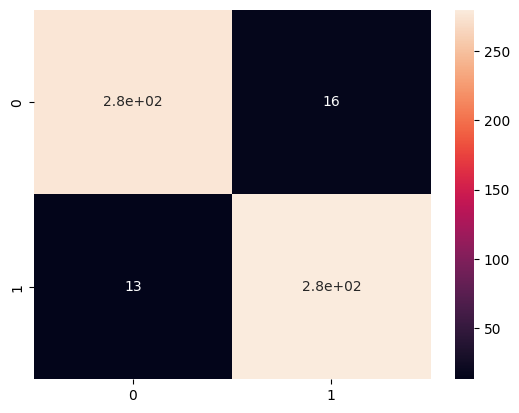

In [31]:
import seaborn as sns
sns.heatmap(cf,annot=True)

In [32]:
precision_score(y_test,lr.predict(x_test))*100

94.5945945945946

In [33]:
recall_score(y_test,lr.predict(x_test))*100

95.56313993174061

In [34]:
f1_score(y_test,lr.predict(x_test))*100

95.07640067911714

In [44]:
import pickle
pickle.dump(lr.fit(x_train, y_train), open("lr_model.pkl", "wb"))
pickle_model=pickle.load(open("lr_model.pkl","rb"))